# 03. Логистическая регрессия: с нуля vs sklearn

Обучаем логистическую регрессию через градиентный спуск (реализация в `src/part1_from_scratch/logistic_regression.py`)
и сравниваем со `sklearn.linear_model.LogisticRegression` на датасете Breast Cancer Wisconsin.


In [1]:
import sys
sys.path.append('../src/part1_from_scratch')

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, confusion_matrix

from logistic_regression import run_comparison


In [2]:
results = run_comparison()


Логистическая регрессия: GD с нуля vs sklearn
--- С нуля (GD) ---
Accuracy:  0.9737
Precision: 0.9859
Recall:    0.9722
F1:        0.9790
ROC-AUC:   0.9957
Confusion matrix:
[[41  1]
 [ 2 70]]

--- sklearn ---
Accuracy:  0.9825
Precision: 0.9861
Recall:    0.9861
F1:        0.9861
ROC-AUC:   0.9954
Confusion matrix:
[[41  1]
 [ 1 71]]



## Кривая обучения (loss по эпохам)


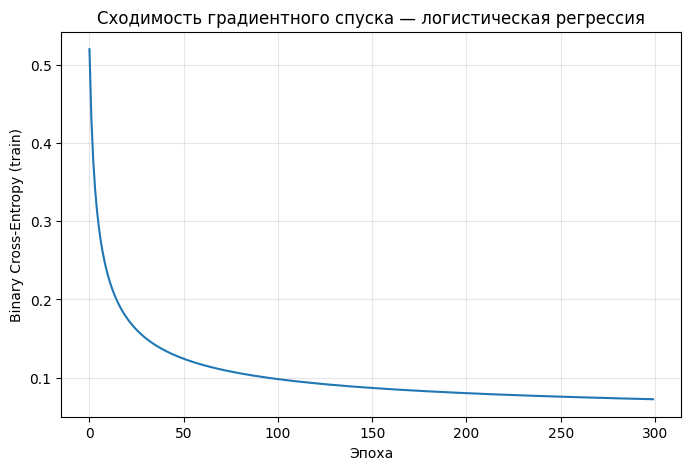

In [3]:
plt.figure(figsize=(8, 5))
plt.plot(results['history'])
plt.xlabel('Эпоха')
plt.ylabel('Binary Cross-Entropy (train)')
plt.title('Сходимость градиентного спуска — логистическая регрессия')
plt.grid(alpha=0.3)
plt.show()


## ROC-кривая: с нуля vs sklearn


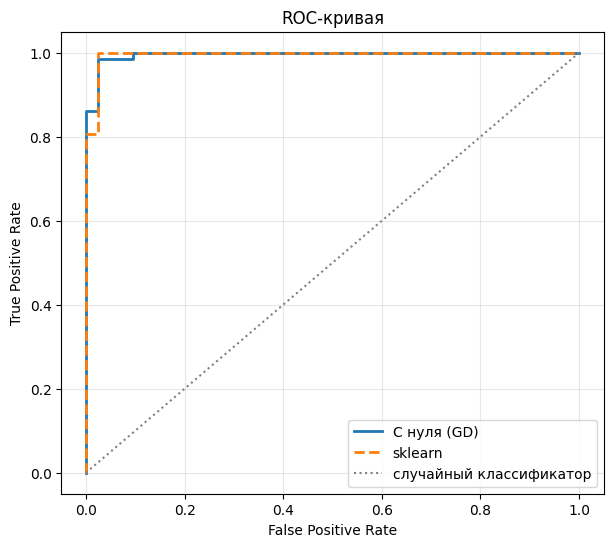

In [4]:
y_test = results['y_test']

fpr_scratch, tpr_scratch, _ = roc_curve(y_test, results['scratch']['y_proba'])
fpr_sklearn, tpr_sklearn, _ = roc_curve(y_test, results['sklearn']['y_proba'])

plt.figure(figsize=(7, 6))
plt.plot(fpr_scratch, tpr_scratch, label='С нуля (GD)', linewidth=2)
plt.plot(fpr_sklearn, tpr_sklearn, label='sklearn', linewidth=2, linestyle='--')
plt.plot([0, 1], [0, 1], color='gray', linestyle=':', label='случайный классификатор')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('../results/logreg_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()


## Confusion matrix


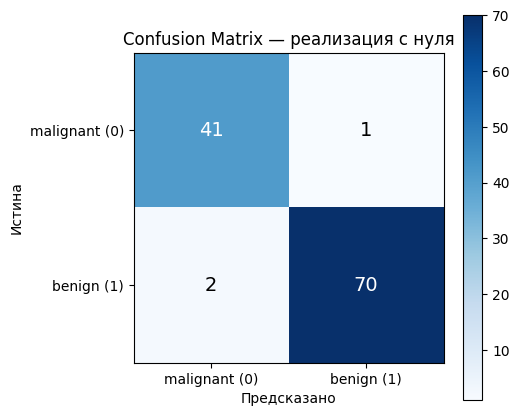

In [6]:
cm = confusion_matrix(y_test, results['scratch']['y_pred'])

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm, cmap='Blues')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['malignant (0)', 'benign (1)'])
ax.set_yticklabels(['malignant (0)', 'benign (1)'])
ax.set_xlabel('Предсказано')
ax.set_ylabel('Истина')
ax.set_title('Confusion Matrix — реализация с нуля')
plt.colorbar(im)
plt.savefig('../results/logreg_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


## Вывод

ROC-AUC нашей реализации практически совпадает со sklearn (см. метрики выше), а ROC-кривые
визуально накладываются друг на друга. Это подтверждает, что градиентный спуск на BCE-loss
сходится к решению, эквивалентному тому, что даёт sklearn через свой (более оптимизированный) солвер.
